In [1]:
import numpy as np
import matplotlib.pyplot as plt

Define Gradients and Hessians

In [2]:
def gradEs(xk, yk, xkp1, ykp1, l_k, k):
    """
    Calculate the gradient of the stretching energy with respect to the coordinates.

    Args:
    - xk (float): x coordinate of the current point
    - yk (float): y coordinate of the current point
    - xkp1 (float): x coordinate of the next point
    - ykp1 (float): y coordinate of the next point
    - l_k (float): reference length
    - EA (float): elastic modulus

    Returns:
    - F (np.array): Gradient array
    """
    F = np.zeros(4)
    F[0] = -(1.0 - np.sqrt((xkp1 - xk)**2.0 + (ykp1 - yk)**2.0) / l_k) * ((xkp1 - xk)**2.0 + (ykp1 - yk)**2.0)**(-0.5) / l_k * (-2.0 * xkp1 + 2.0 * xk)
    F[1] = -(0.1e1 - np.sqrt((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) / l_k) * ((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.1e1 / 0.2e1) / l_k * (-0.2e1 * ykp1 + 0.2e1 * yk)
    F[2] = -(0.1e1 - np.sqrt((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) / l_k) * ((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.1e1 / 0.2e1) / l_k * (0.2e1 * xkp1 - 0.2e1 * xk)
    F[3] = -(0.1e1 - np.sqrt((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) / l_k) * ((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.1e1 / 0.2e1) / l_k * (0.2e1 * ykp1 - 0.2e1 * yk)

    F = 0.5 * k * l_k * F  # Scale by k and l_k

    return F

In [3]:
def hessEs(xk, yk, xkp1, ykp1, l_k, k):
    """
    This function returns the 4x4 Hessian of the stretching energy E_k^s with
    respect to x_k, y_k, x_{k+1}, and y_{k+1}.
    """
    J = np.zeros((4, 4))  # Initialize the Hessian matrix
    J11 = (1 / ((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) / l_k ** 2 * (-2 * xkp1 + 2 * xk) ** 2) / 0.2e1 + (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.3e1 / 0.2e1)) / l_k * ((-2 * xkp1 + 2 * xk) ** 2) / 0.2e1 - 0.2e1 * (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.1e1 / 0.2e1)) / l_k
    J12 = (1 / ((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) / l_k ** 2 * (-2 * ykp1 + 2 * yk) * (-2 * xkp1 + 2 * xk)) / 0.2e1 + (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.3e1 / 0.2e1)) / l_k * (-2 * xkp1 + 2 * xk) * (-2 * ykp1 + 2 * yk) / 0.2e1
    J13 = (1 / ((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) / l_k ** 2 * (2 * xkp1 - 2 * xk) * (-2 * xkp1 + 2 * xk)) / 0.2e1 + (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.3e1 / 0.2e1)) / l_k * (-2 * xkp1 + 2 * xk) * (2 * xkp1 - 2 * xk) / 0.2e1 + 0.2e1 * (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.1e1 / 0.2e1)) / l_k
    J14 = (1 / ((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) / l_k ** 2 * (2 * ykp1 - 2 * yk) * (-2 * xkp1 + 2 * xk)) / 0.2e1 + (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.3e1 / 0.2e1)) / l_k * (-2 * xkp1 + 2 * xk) * (2 * ykp1 - 2 * yk) / 0.2e1
    J22 = (1 / ((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) / l_k ** 2 * (-2 * ykp1 + 2 * yk) ** 2) / 0.2e1 + (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.3e1 / 0.2e1)) / l_k * ((-2 * ykp1 + 2 * yk) ** 2) / 0.2e1 - 0.2e1 * (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.1e1 / 0.2e1)) / l_k
    J23 = (1 / ((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) / l_k ** 2 * (2 * xkp1 - 2 * xk) * (-2 * ykp1 + 2 * yk)) / 0.2e1 + (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.3e1 / 0.2e1)) / l_k * (-2 * ykp1 + 2 * yk) * (2 * xkp1 - 2 * xk) / 0.2e1
    J24 = (1 / ((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) / l_k ** 2 * (2 * ykp1 - 2 * yk) * (-2 * ykp1 + 2 * yk)) / 0.2e1 + (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.3e1 / 0.2e1)) / l_k * (-2 * ykp1 + 2 * yk) * (2 * ykp1 - 2 * yk) / 0.2e1 + 0.2e1 * (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.1e1 / 0.2e1)) / l_k
    J33 = (1 / ((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) / l_k ** 2 * (2 * xkp1 - 2 * xk) ** 2) / 0.2e1 + (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.3e1 / 0.2e1)) / l_k * ((2 * xkp1 - 2 * xk) ** 2) / 0.2e1 - 0.2e1 * (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.1e1 / 0.2e1)) / l_k
    J34 = (1 / ((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) / l_k ** 2 * (2 * ykp1 - 2 * yk) * (2 * xkp1 - 2 * xk)) / 0.2e1 + (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.3e1 / 0.2e1)) / l_k * (2 * xkp1 - 2 * xk) * (2 * ykp1 - 2 * yk) / 0.2e1
    J44 = (1 / ((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) / l_k ** 2 * (2 * ykp1 - 2 * yk) ** 2) / 0.2e1 + (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.3e1 / 0.2e1)) / l_k * ((2 * ykp1 - 2 * yk) ** 2) / 0.2e1 - 0.2e1 * (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.1e1 / 0.2e1)) / l_k

    J = np.array([[J11, J12, J13, J14],
                   [J12, J22, J23, J24],
                   [J13, J23, J33, J34],
                   [J14, J24, J34, J44]])

    J *= 0.5 * k * l_k

    return J

[ ]
import numpy as np
import matplotlib.pyplot as plt
Define Gradients and Hessians

[ ]
def gradEs(xk, yk, xkp1, ykp1, l_k, k):
    """
    Calculate the gradient of the stretching energy with respect to the coordinates.

    Args:
    - xk (float): x coordinate of the current point
    - yk (float): y coordinate of the current point
    - xkp1 (float): x coordinate of the next point
    - ykp1 (float): y coordinate of the next point
    - l_k (float): reference length
    - EA (float): elastic modulus

    Returns:
    - F (np.array): Gradient array
    """
    F = np.zeros(4)
    F[0] = -(1.0 - np.sqrt((xkp1 - xk)**2.0 + (ykp1 - yk)**2.0) / l_k) * ((xkp1 - xk)**2.0 + (ykp1 - yk)**2.0)**(-0.5) / l_k * (-2.0 * xkp1 + 2.0 * xk)
    F[1] = -(0.1e1 - np.sqrt((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) / l_k) * ((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.1e1 / 0.2e1) / l_k * (-0.2e1 * ykp1 + 0.2e1 * yk)
    F[2] = -(0.1e1 - np.sqrt((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) / l_k) * ((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.1e1 / 0.2e1) / l_k * (0.2e1 * xkp1 - 0.2e1 * xk)
    F[3] = -(0.1e1 - np.sqrt((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) / l_k) * ((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.1e1 / 0.2e1) / l_k * (0.2e1 * ykp1 - 0.2e1 * yk)

    F = 0.5 * k * l_k * F  # Scale by k and l_k

    return F

[ ]
                   [J13, J23, J33, J34],
                   [J14, J24, J34, J44]])

    J *= 0.5 * k * l_k

    return J

Write Node and Properties to Files

In [4]:
%%writefile nodes_b.txt
0, 0
1, 0
2, 0
1, -1


Writing nodes_b.txt


In [5]:
%%writefile nodes_a.txt
0, 0
1, 0
2, 0

Writing nodes_a.txt


In [6]:
%%writefile springs_a.txt
0, 1, 10
1, 2, 20


Writing springs_a.txt


In [7]:
%%writefile springs_b.txt
0, 1, 10
1, 2, 20
2, 3, 5
0, 3, 5

Writing springs_b.txt


Read the Nodes, Springs and Properties

In [8]:
nodes_file_path = 'nodes_b.txt'
node_coordinates = []

try:
    with open(nodes_file_path, 'r') as f:
        for line in f:
            # Split each line by comma and remove leading/trailing whitespace
            parts = [part.strip() for part in line.split(',')]
            # Assuming the format is x, y
            # We only need x and y, which are the first and second elements (index 0 and 1)
            if len(parts) == 2:
                try:
                    x = float(parts[0])
                    y = float(parts[1])
                    node_coordinates.append([x, y])
                except ValueError:
                    print(f"Skipping line due to non-numeric coordinates: {line.strip()}")
            else:
                print(f"Skipping line due to incorrect format: {line.strip()}")

    # Convert the list of coordinates to a NumPy array
    node_matrix = np.array(node_coordinates)

    print("Node coordinates successfully loaded into a numpy matrix.")
    display(node_matrix)

except FileNotFoundError:
    print(f"Error: The file '{nodes_file_path}' was not found.")
except Exception as e:
    print(f"An error occurred: {e}")

Node coordinates successfully loaded into a numpy matrix.


array([[ 0.,  0.],
       [ 1.,  0.],
       [ 2.,  0.],
       [ 1., -1.]])

In [9]:
springs_file_path = 'springs_b.txt'
index_info = []
stiffness_info = []

try:
    with open(springs_file_path, 'r') as f:
        for line in f:
            # Split each line by comma and remove leading/trailing whitespace
            parts = [part.strip() for part in line.split(',')]
            # Assuming the format is spring number, first node, second node, stiffness
            if len(parts) == 3:
                try:
                    first_node_index = float(parts[0])
                    second_node_index = float(parts[1])
                    stiffness = float(parts[2])
                    index_info.append([2*first_node_index, 2*first_node_index+1, 2*second_node_index, 2*second_node_index+1])
                    stiffness_info.append(stiffness)
                except ValueError:
                    print(f"Skipping line due to non-numeric coordinates: {line.strip()}")
            else:
                print(f"Skipping line due to incorrect format: {line.strip()}")

    # Convert the list of coordinates to a NumPy array
    index_matrix = np.array(index_info)
    stiffness_matrix = np.array(stiffness_info)

    print("Spring indices successfully loaded into a numpy matrix.")
    display(index_matrix)

    print("Spring stiffnesses successfully loaded into a numpy matrix.")
    display(stiffness_matrix)

except FileNotFoundError:
    print(f"Error: The file '{springs_file_path}' was not found.")
except Exception as e:
    print(f"An error occurred: {e}")

Spring indices successfully loaded into a numpy matrix.


array([[0., 1., 2., 3.],
       [2., 3., 4., 5.],
       [4., 5., 6., 7.],
       [0., 1., 6., 7.]])

Spring stiffnesses successfully loaded into a numpy matrix.


array([10., 20.,  5.,  5.])

Equations of motion and Jacobian

In [10]:
def getFexternal(m):

  # Input: mass (m) is a vector of size ndof ( = 2 times number of nodes)
  # Output: weight (W) is a vector of same size

  W = np.zeros_like(m)
  for i in range(len(m) // 2 ):
    W[2 * i] = 0.0
    W[2 * i + 1] = m[2 * i + 1] * (-9.8)
  return W

In [11]:
def getForceJacobian(x_new, x_old, u_old, stiffness_matrix, index_matrix, m, dt, l_k):

  ndof = x_new.shape[0]

  # Inertia
  f_inertia = m/dt * ((x_new - x_old)/dt - u_old)
  J_inertia = np.diag(m) / dt ** 2

  # Spring
  f_spring = np.zeros_like(x_new)
  J_spring = np.zeros((ndof,ndof))
  for i in range(stiffness_matrix.shape[0]):
    ind = index_matrix[i].astype(int)
    xi = x_new[ind[0]]
    yi = x_new[ind[1]]
    xj = x_new[ind[2]]
    yj = x_new[ind[3]]
    stiffness = stiffness_matrix[i]
    f_spring[ind] += gradEs(xi, yi, xj, yj, l_k[i], stiffness)
    J_spring[np.ix_(ind, ind)] += hessEs(xi, yi, xj, yj, l_k[i], stiffness)

  # External force
  f_ext = getFexternal(m)
  J_ext = np.zeros((ndof,ndof))

  f = f_inertia + f_spring - f_ext
  J = J_inertia + J_spring - J_ext

  return f, J

Preparation at t=0

In [12]:
N = node_matrix.shape[0] # Number of nodes
ndof = 2 * N # Number of degrees of freedom
print(N)
print(ndof)

# Initialize positions, velocities, and accelerations
x_old = np.zeros(ndof)
u_old = np.zeros(ndof)
a_old = np.zeros(ndof)

# Build the position (DOF) vector. Velocity and acceleration remains zero
for i in range(N):
  x_old[2*i] = node_matrix[i][0]
  x_old[2*i+1] = node_matrix[i][1]

# Every spring has a rest length
l_k = np.zeros_like(stiffness_matrix)
for i in range(stiffness_matrix.shape[0]):
  ind = index_matrix[i].astype(int)  # Convert indices to integers
  xi = x_old[ind[0]]
  yi = x_old[ind[1]]
  xj = x_old[ind[2]]
  yj = x_old[ind[3]]
  l_k[i] = np.sqrt((xj - xi)**2 + (yj - yi)**2)

4
8


Mass and Weight

In [13]:
# Mass
m = np.zeros(ndof)
for i in range(ndof):
  m[i] = 1.0

# Weight
W = getFexternal(m)

Simulation Loop

Simulate/ Integrate function

In [14]:
# Integrator
def myInt(t_new, x_old, u_old, free_DOF, stiffness_matrix, index_matrix, m, dt):

  # Guess solution for x_new
  x_new = x_old.copy() # Start with a copy of x_old as the initial guess

  eps = 1.0e-6 # tolerance
  err = eps * 100  # initialize to a large value

  # Newton-Raphson method
  while err > eps:
    f, J = getForceJacobian(x_new, x_old, u_old, stiffness_matrix, index_matrix, m, dt, l_k)

    # Extract free DOFs
    J_free = J[np.ix_(free_DOF, free_DOF)]
    f_free = f[free_DOF]

    # Solve for deltaX of free DOFs
    deltaX_free = np.linalg.solve(J_free, f_free)

    # Construct full deltaX vector
    deltaX = np.zeros_like(x_new)
    deltaX[free_DOF] = deltaX_free

    # Update x_new
    x_new = x_new - deltaX

    # Calculate error based on the force in free DOFs
    err = np.linalg.norm(f_free)

  u_new = (x_new - x_old) / dt

  return x_new, u_new

Plotting function

In [15]:
def plot(x, index_matrix, t):
  plt.figure() # Create a new figure for each plot
  plt.title(f'Time: {t:.2f} second') # Add a title with the current time
  for i in range(index_matrix.shape[0]):
    ind = index_matrix[i].astype(int)  # Convert indices to integers
    xi = x[ind[0]]
    yi = x[ind[1]]
    xj = x[ind[2]]
    yj = x[ind[3]]
    plt.plot([xi, xj], [yi, yj], 'bo-') # Plot a blue line with circles at the nodes
  plt.xlabel('x')
  plt.ylabel('y')
  plt.axis('equal') # Ensure equal scaling for x and y axes
  plt.grid(True)
  plt.show()

Main simulation loop

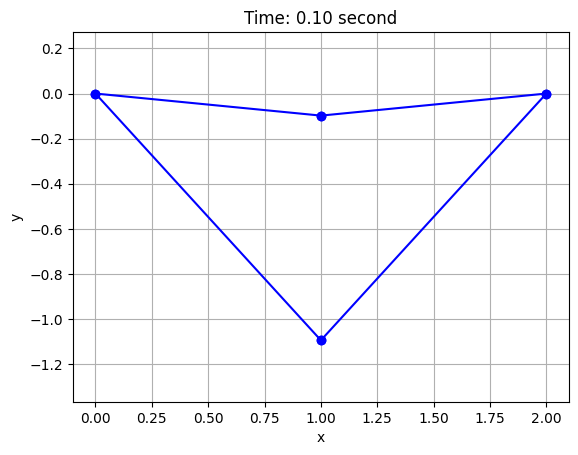

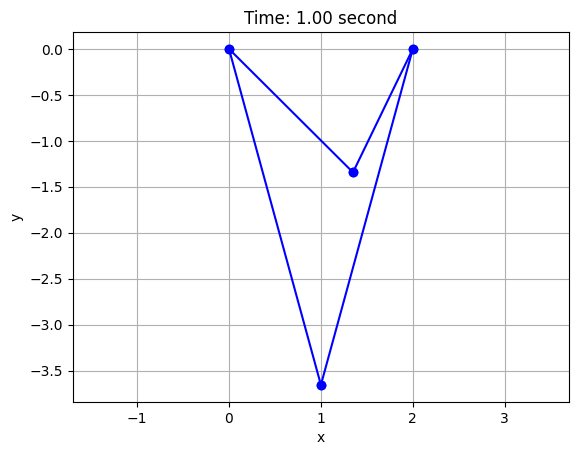

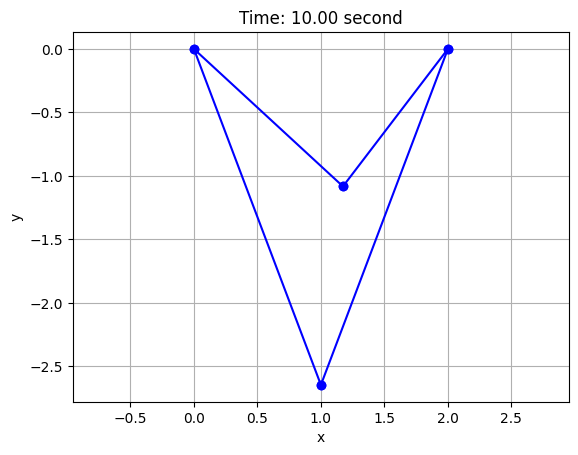

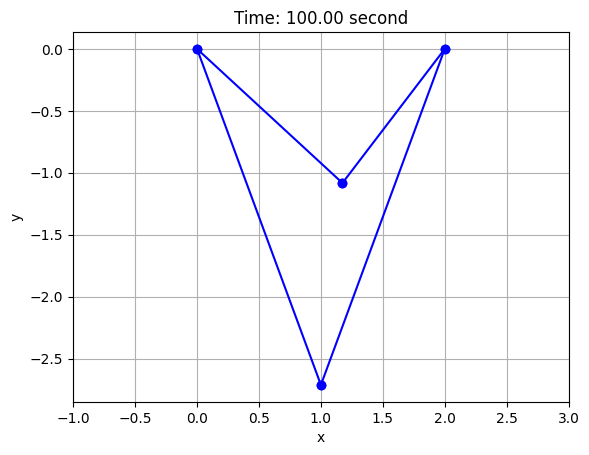

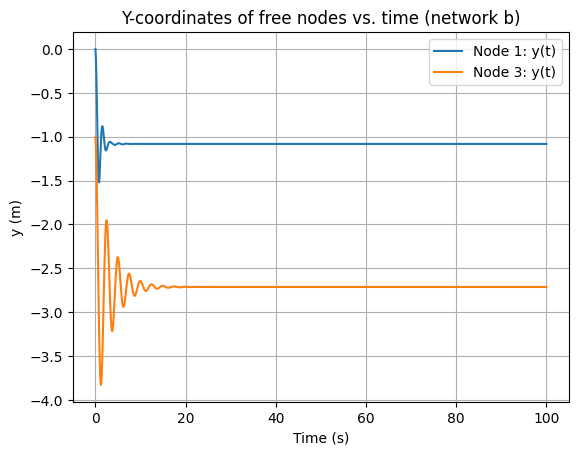

In [16]:
dt = 0.1 # Time step size
maxTime = 100   # total time of simulation
t = np.arange(0, maxTime + dt, dt)

# free indices
fixed_DOF = np.array([0, 1, 4, 5], dtype=int)
free_DOF = np.setdiff1d(np.arange(ndof, dtype=int), fixed_DOF)

# Container to store y-coordinate of node_1 and node_3
dof_y_node1 = 3
dof_y_node3 = 7
y1 = np.zeros_like(t)
y3 = np.zeros_like(t)
y1[0] = x_old[dof_y_node1]
y3[0] = x_old[dof_y_node3]

#plotting time
snap_times = np.array([0.0, 0.1, 1.0, 10.0, 100.0])
snap_tol = 0.5 * dt

for k in range(len(t) - 1):
  t_new = t[k + 1]

  x_new, u_new = myInt(t_new, x_old, u_old, free_DOF,
                        stiffness_matrix, index_matrix, m, dt)
  if np.any(np.abs(t_new - snap_times) < snap_tol):
      plot(x_new, index_matrix, t_new)
  y1[k + 1] = x_new[dof_y_node1]
  y3[k + 1] = x_new[dof_y_node3]

  x_old = x_new
  u_old = u_new

# Plot
plt.figure()
plt.plot(t, y1, label='Node 1: y(t)')
plt.plot(t, y3, label='Node 3: y(t)')
plt.xlabel('Time (s)')
plt.ylabel('y (m)')
plt.title('Y-coordinates of free nodes vs. time (network b)')
plt.grid(True)
plt.legend()
plt.show()

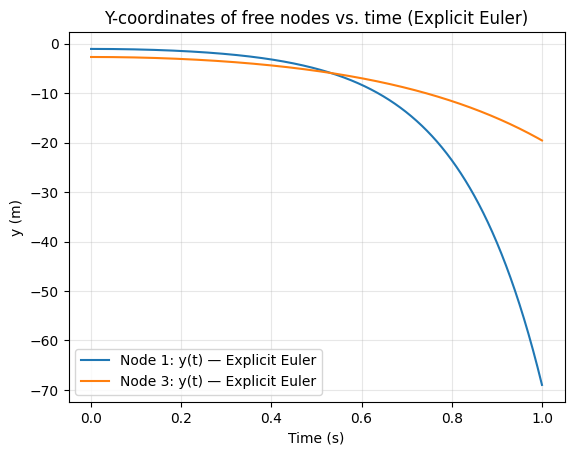

In [17]:
# Explicit
def assemble_f_spring(x, stiffness_matrix, index_matrix, l_k):
    f_spring = np.zeros_like(x)
    for i in range(stiffness_matrix.shape[0]):
        ind = index_matrix[i].astype(int)  # [xi, yi, xj, yj]
        xi, yi, xj, yj = x[ind[0]], x[ind[1]], x[ind[2]], x[ind[3]]
        k_e = stiffness_matrix[i]
        l0 = l_k[i]
        f_e = gradEs(xi, yi, xj, yj, l0, k_e)
        f_spring[ind] += f_e
    return f_spring


def simulate_explicit_fixed_dt(dt, t_end=1.0):
    global x_old, u_old, m, index_matrix, stiffness_matrix, l_k, fixed_DOF

    # Reference positions of fixed DOFs
    x_fix_ref = x_old.copy()

    # External forces (gravity)
    W = getFexternal(m).copy()
    if len(fixed_DOF) > 0:
        W[fixed_DOF] = 0.0  # zero out forces on constrained DOFs

    # DOFs to track for plotting (y of node 1 and node 3)
    dof_y1, dof_y3 = 3, 7

    # Generate time vector
    n_steps = int(np.ceil(t_end / dt))
    times = np.linspace(0.0, n_steps * dt, n_steps + 1)

    # Initialize state
    x = x_old.copy()
    u = u_old.copy()

    # Apply initial constraints
    if len(fixed_DOF) > 0:
        x[fixed_DOF] = x_fix_ref[fixed_DOF]
        u[fixed_DOF] = 0.0

    # Record initial y positions
    y1 = np.empty(n_steps + 1)
    y3 = np.empty(n_steps + 1)
    y1[0] = x[dof_y1]
    y3[0] = x[dof_y3]

    # Explicit Euler main loop
    for k in range(n_steps):
        # Compute total forces
        f_spring = assemble_f_spring(x, stiffness_matrix, index_matrix, l_k)
        f_net = f_spring + W

        # Update using explicit Euler
        a = f_net / np.maximum(m, 1e-30)
        u_new = u + dt * a
        x_new = x + dt * u

        # Reapply constraints
        if len(fixed_DOF) > 0:
            x_new[fixed_DOF] = x_fix_ref[fixed_DOF]
            u_new[fixed_DOF] = 0.0

        x, u = x_new, u_new
        y1[k + 1] = x[dof_y1]
        y3[k + 1] = x[dof_y3]

    return times, y1, y3


# manually change dt below
t_exp, y1_exp, y3_exp = simulate_explicit_fixed_dt(dt=1e-3, t_end=1.0)

# Plot
plt.figure()
plt.plot(t_exp, y1_exp, label='Node 1: y(t) — Explicit Euler')
plt.plot(t_exp, y3_exp, label='Node 3: y(t) — Explicit Euler')
plt.xlabel('Time (s)')
plt.ylabel('y (m)')
plt.title('Y-coordinates of free nodes vs. time (Explicit Euler)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


In [19]:

# Newmark-beta integrator: beta=1/4, gamma=1/2
# This cell relies on existing functions/variables: gradEs, hessEs, index_matrix, stiffness_matrix, l_k, m, fixed_DOF, x_old, u_old
import numpy as np

def assemble_internal_force(x, stiffness_matrix, index_matrix, l_k):
    # Assemble internal spring forces using gradEs.
    fint = np.zeros_like(x)
    for e in range(stiffness_matrix.shape[0]):
        ind = index_matrix[e].astype(int)  # [xi, yi, xj, yj]
        xi, yi, xj, yj = x[ind[0]], x[ind[1]], x[ind[2]], x[ind[3]]
        fe = gradEs(xi, yi, xj, yj, l_k[e], stiffness_matrix[e])
        fint[ind] += fe
    return fint

def assemble_tangent(x, stiffness_matrix, index_matrix, l_k):
    # Assemble tangent stiffness using hessEs.
    ndof = x.size
    K = np.zeros((ndof, ndof))
    for e in range(stiffness_matrix.shape[0]):
        ind = index_matrix[e].astype(int)
        xi, yi, xj, yj = x[ind[0]], x[ind[1]], x[ind[2]], x[ind[3]]
        Ke = hessEs(xi, yi, xj, yj, l_k[e], stiffness_matrix[e])
        K[np.ix_(ind, ind)] += Ke
    return K

def newmark_beta(x0, u0, m, index_matrix, stiffness_matrix, l_k,
                 fext_func=None, dt=1e-2, t_end=1.0, beta=1/4, gamma=1/2, fixed_DOF=()):
    ndof = x0.size
    M = np.asarray(m, float)
    Minv = 1.0 / np.maximum(M, 1e-30)

    n_steps = int(np.ceil(t_end / dt))
    times = np.linspace(0.0, n_steps*dt, n_steps+1)
    X = np.zeros((n_steps+1, ndof))
    U = np.zeros((n_steps+1, ndof))
    A = np.zeros((n_steps+1, ndof))

    x = x0.copy()
    u = u0.copy()
    fext0 = fext_func(0.0) if fext_func is not None else np.zeros(ndof)
    a = (fext0 - assemble_internal_force(x, stiffness_matrix, index_matrix, l_k)) * Minv

    if len(fixed_DOF) > 0:
        x[fixed_DOF] = x0[fixed_DOF]
        u[fixed_DOF] = 0.0
        a[fixed_DOF] = 0.0

    X[0], U[0], A[0] = x.copy(), u.copy(), a.copy()

    for k in range(n_steps):
        t_np1 = times[k+1]
        fext = fext_func(t_np1) if fext_func is not None else np.zeros(ndof)

        x_pred = x + dt*u + (0.5 - beta)*dt*dt*a
        u_pred = u + (1.0 - gamma)*dt*a

        a_np1 = A[k].copy()
        for it in range(50):
            x_trial = x_pred + beta*dt*dt*a_np1
            u_trial = u_pred + gamma*dt*a_np1

            fint = assemble_internal_force(x_trial, stiffness_matrix, index_matrix, l_k)
            Kt = assemble_tangent(x_trial, stiffness_matrix, index_matrix, l_k)

            r = M*a_np1 + fint - fext
            J = np.diag(M) + beta*dt*dt*Kt

            if len(fixed_DOF) > 0:
                free = np.setdiff1d(np.arange(ndof), fixed_DOF)
                dA_free = np.linalg.solve(J[np.ix_(free, free)], -r[free])
                dA = np.zeros_like(a_np1); dA[free] = dA_free
            else:
                dA = np.linalg.solve(J, -r)

            a_np1 = a_np1 + dA

            if len(fixed_DOF) > 0:
                err = np.linalg.norm((M*a_np1 + assemble_internal_force(x_pred + beta*dt*dt*a_np1, stiffness_matrix, index_matrix, l_k) - fext)[free])
            else:
                err = np.linalg.norm(M*a_np1 + assemble_internal_force(x_pred + beta*dt*dt*a_np1, stiffness_matrix, index_matrix, l_k) - fext)
            if err < 1e-8:
                break

        x_new = x_pred + beta*dt*dt*a_np1
        u_new = u_pred + gamma*dt*a_np1

        if len(fixed_DOF) > 0:
            x_new[fixed_DOF] = x0[fixed_DOF]
            u_new[fixed_DOF] = 0.0
            a_np1[fixed_DOF] = 0.0

        x, u, a = x_new, u_new, a_np1
        X[k+1], U[k+1], A[k+1] = x.copy(), u.copy(), a.copy()

    return times, X, U, A


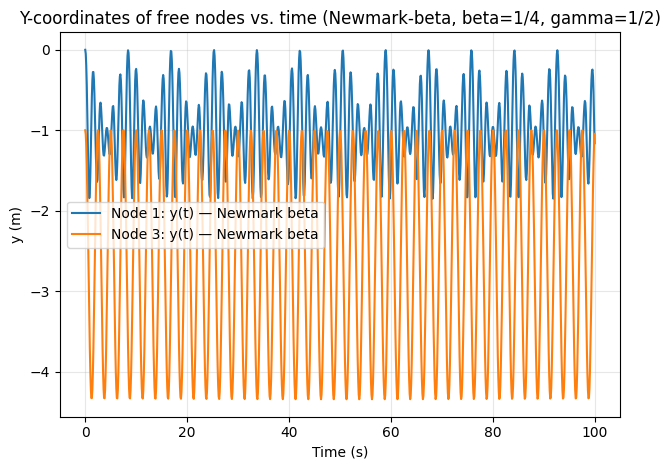

In [24]:

# Run Newmark-beta on current network and plot y(t) for two free nodes
import numpy as np
import matplotlib.pyplot as plt

def fext_func(t):

    return getFexternal(m)

x0 = np.array([0.0,0.0,  1.0,0.0,  2.0,0.0,  1.0,-1.0])
u0 = np.zeros_like(x0)

t_nm, X_nm, U_nm, A_nm = newmark_beta(
    x0=x0, u0=u0, m=m,
    index_matrix=index_matrix, stiffness_matrix=stiffness_matrix, l_k=l_k,
    fext_func=fext_func,
    dt=0.1, t_end=100.0,
    beta=1/4, gamma=1/2,
    fixed_DOF=fixed_DOF
)


dof_y1, dof_y3 = 3, 7

plt.figure()
plt.plot(t_nm, X_nm[:, dof_y1], label='Node 1: y(t) — Newmark beta')
plt.plot(t_nm, X_nm[:, dof_y3], label='Node 3: y(t) — Newmark beta')
plt.xlabel('Time (s)'); plt.ylabel('y (m)')
plt.title('Y-coordinates of free nodes vs. time (Newmark-beta, beta=1/4, gamma=1/2)')
plt.grid(True, alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()
